In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("retail_sales.xlsx.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [5]:
import os

print(os.getcwd())
print(os.listdir())


C:\Users\Admin\OneDrive\Documents\DataAnalytics-L1-EDARetailSales
['.ipynb_checkpoints', 'retail_sales.xlsx.csv', 'Retail_Sales_EDA.ipynb']


In [6]:
df = pd.read_csv("retail_sales.xlsx.csv")

df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
print("Rows and Columns:", df.shape)
print("\nColumn Names:")
print(df.columns)

Rows and Columns: (1000, 9)

Column Names:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [9]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [31]:
df['Date'] = pd.to_datetime(df['Date'])

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [15]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2023-01-01
End Date: 2024-01-01


In [16]:
print("Age range:", df['Age'].min(), "to", df['Age'].max())
print("Quantity range:", df['Quantity'].min(), "to", df['Quantity'].max())
print("Price range:", df['Price per Unit'].min(), "to", df['Price per Unit'].max())
print("Total Amount range:", df['Total Amount'].min(), "to", df['Total Amount'].max())

Age range: 18 to 64
Quantity range: 1 to 4
Price range: 25 to 500
Total Amount range: 25 to 2000


In [17]:
print("Gender values:")
print(df['Gender'].value_counts())

print("\nProduct Category values:")
print(df['Product Category'].value_counts())

Gender values:
Gender
Female    510
Male      490
Name: count, dtype: int64

Product Category values:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


In [18]:
total_sales = df['Total Amount'].sum()
average_sales = df['Total Amount'].mean()

print("Total Sales:", total_sales)
print("Average Sales per Transaction:", average_sales)

Total Sales: 456000
Average Sales per Transaction: 456.0


In [19]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

print(category_sales)

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


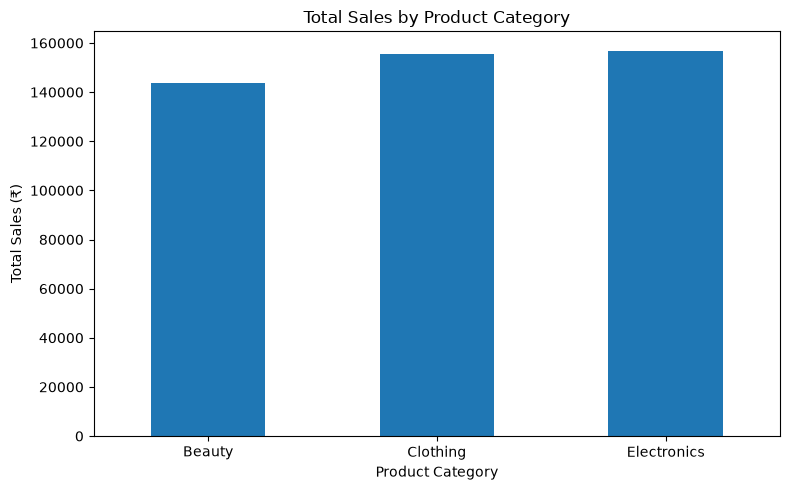

In [20]:
plt.figure(figsize=(8, 5))

category_sales.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

print(gender_sales)

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


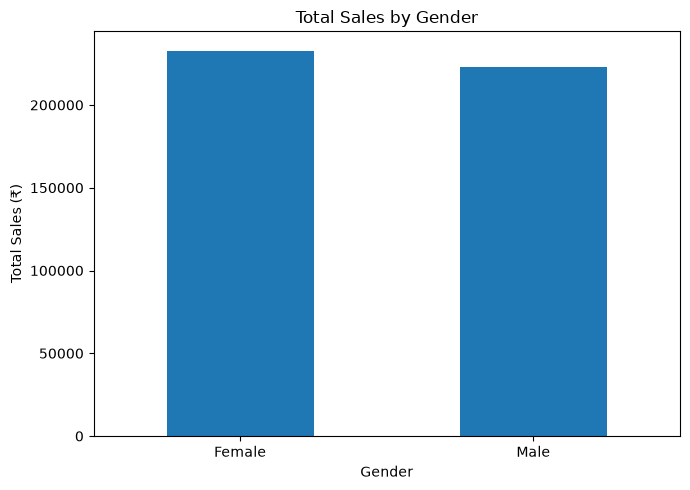

In [22]:
plt.figure(figsize=(7, 5))

gender_sales.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
df['Date'] = pd.to_datetime(df['Date'])

In [32]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(
    df['Date'].dt.to_period('M')
)['Total Amount'].sum()

print(monthly_sales)

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


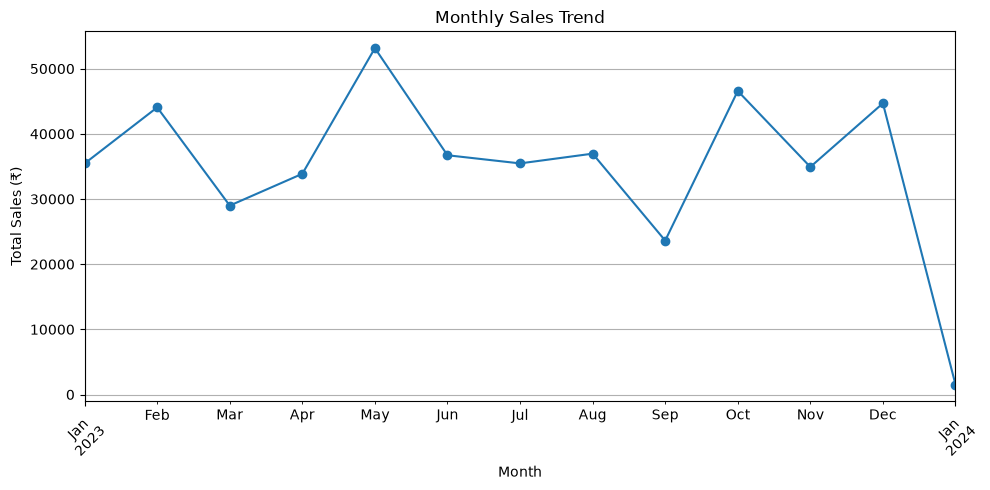

In [33]:
plt.figure(figsize=(10, 5))

monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

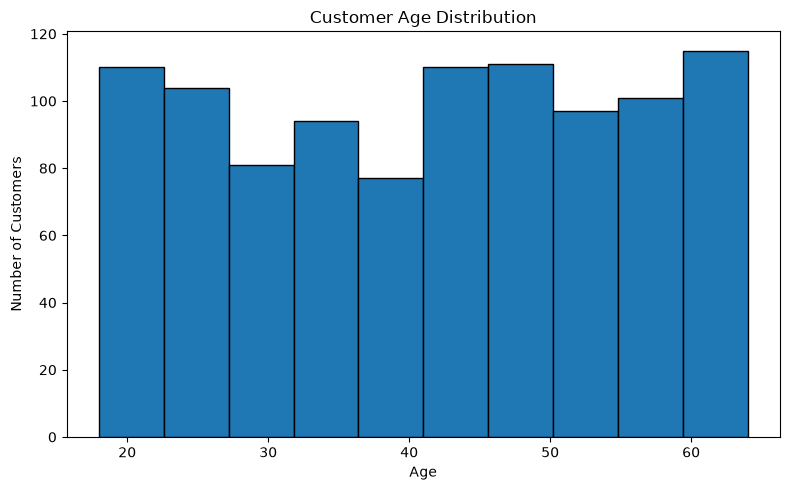

In [34]:
plt.figure(figsize=(8, 5))

plt.hist(df['Age'], bins=10, edgecolor='black')

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

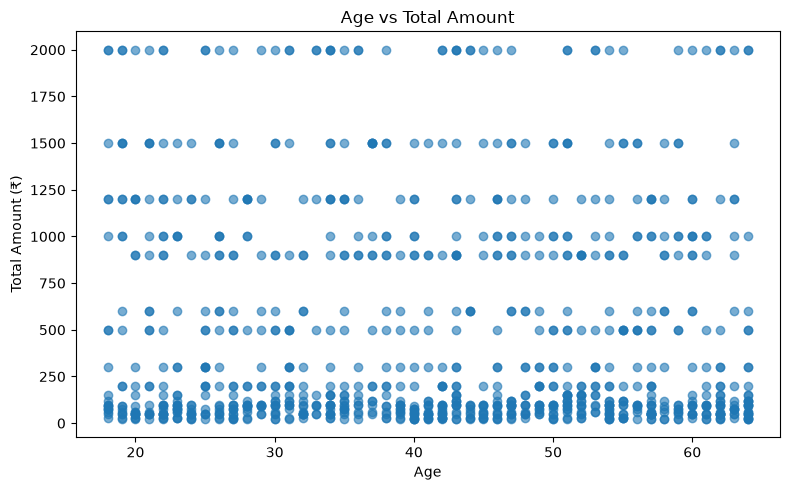

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(df['Age'], df['Total Amount'], alpha=0.6)

plt.title('Age vs Total Amount')
plt.xlabel('Age')
plt.ylabel('Total Amount (₹)')
plt.tight_layout()
plt.show()

In [36]:
correlation = df['Age'].corr(df['Total Amount'])

print("Correlation between Age and Total Amount:", correlation)

Correlation between Age and Total Amount: -0.060568023883045656


In [37]:
category_gender_sales = df.groupby(
    ['Product Category', 'Gender']
)['Total Amount'].sum().unstack()

print(category_gender_sales)

Gender            Female   Male
Product Category               
Beauty             74830  68685
Clothing           81275  74305
Electronics        76735  80170


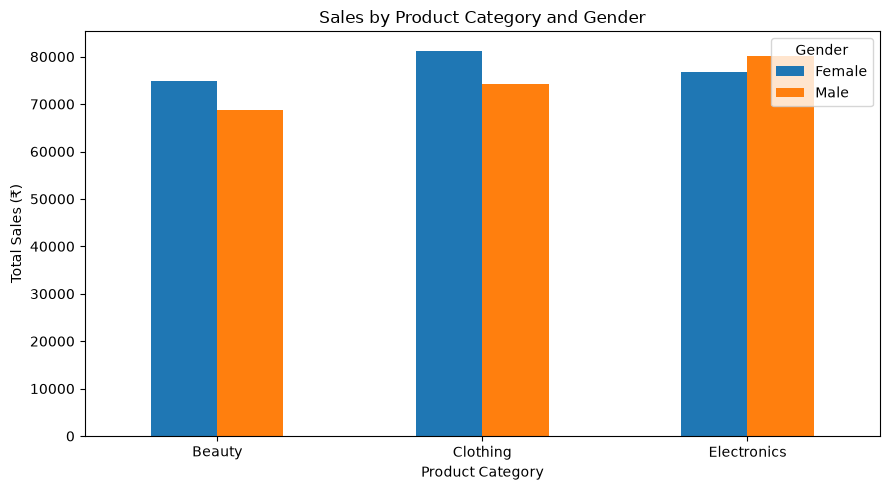

In [38]:
category_gender_sales.plot(kind='bar', figsize=(9, 5))

plt.title('Sales by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [39]:
category_quantity = df.groupby('Product Category')['Quantity'].sum()

print(category_quantity)

Product Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64


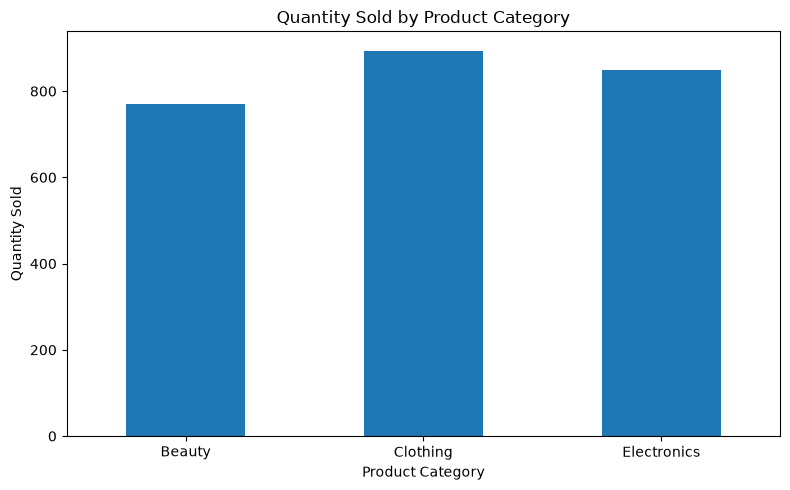

In [40]:
plt.figure(figsize=(8, 5))

category_quantity.plot(kind='bar')

plt.title('Quantity Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [41]:
category_avg_sales = df.groupby('Product Category')['Total Amount'].mean()

print(category_avg_sales)

Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64


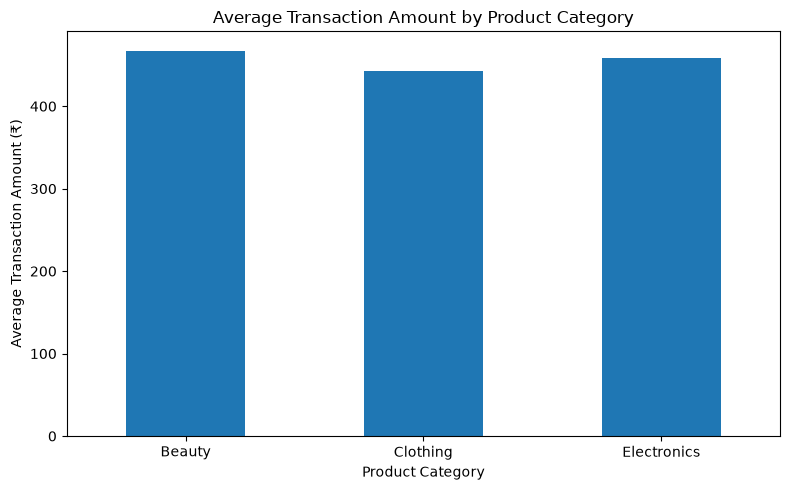

In [42]:
plt.figure(figsize=(8, 5))

category_avg_sales.plot(kind='bar')

plt.title('Average Transaction Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Transaction Amount (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [43]:
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-64']

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

age_group_sales = df.groupby(
    'Age Group',
    observed=True
)['Total Amount'].sum()

print(age_group_sales)

Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56-64     80410
Name: Total Amount, dtype: int64


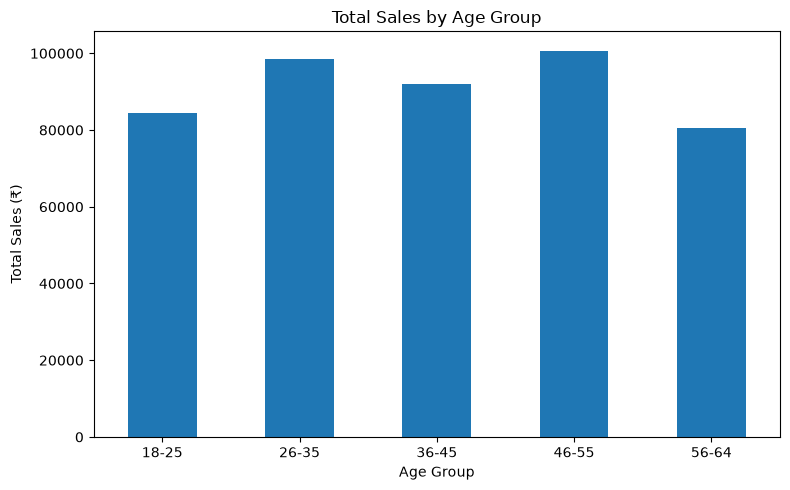

In [44]:
plt.figure(figsize=(8, 5))

age_group_sales.plot(kind='bar')

plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [45]:
numeric_df = df[
    ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
]

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


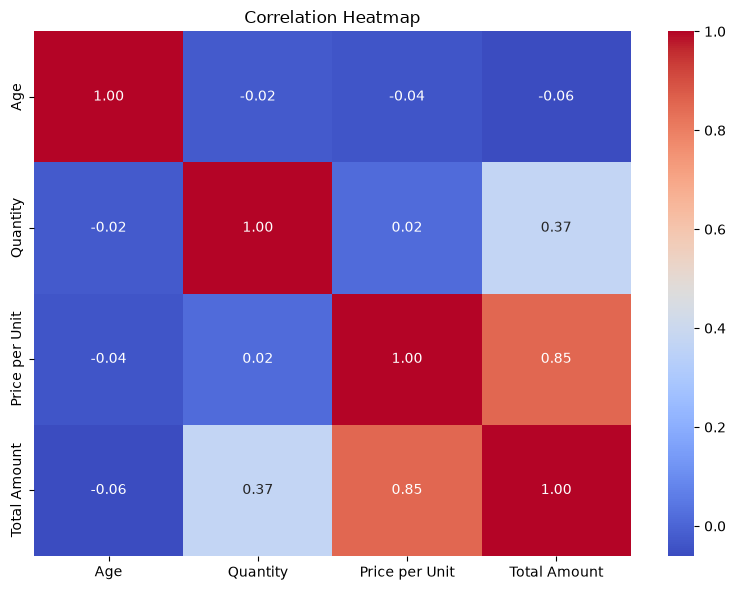

In [46]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [47]:
top_transactions = df.nlargest(10, 'Total Amount')

print(
    top_transactions[
        ['Transaction ID', 'Customer ID', 'Product Category',
         'Quantity', 'Price per Unit', 'Total Amount']
    ]
)

     Transaction ID Customer ID Product Category  Quantity  Price per Unit  \
14               15     CUST015      Electronics         4             500   
64               65     CUST065      Electronics         4             500   
71               72     CUST072      Electronics         4             500   
73               74     CUST074           Beauty         4             500   
88               89     CUST089      Electronics         4             500   
92               93     CUST093           Beauty         4             500   
108             109     CUST109      Electronics         4             500   
117             118     CUST118      Electronics         4             500   
123             124     CUST124         Clothing         4             500   
138             139     CUST139           Beauty         4             500   

     Total Amount  
14           2000  
64           2000  
71           2000  
73           2000  
88           2000  
92           2000  
1

Key Findings

1. Overall Sales

- Total sales generated: ₹4,56,000.
- Average transaction value: ₹456.
- The dataset contains 1,000 retail transactions.

2. Product Category Performance

- Electronics generated the highest total sales at ₹1,56,905.
- Clothing generated ₹1,55,580.
- Beauty generated ₹1,14,515.
- Clothing had the highest quantity sold with 894 units.

3. Gender-wise Sales

- Female customers generated ₹2,32,840 in sales.
- Male customers generated ₹2,23,160.
- Female customers contributed slightly higher sales overall.

4. Customer Age Analysis

- The 46–55 age group generated the highest sales at ₹1,00,690.
- The 56–64 age group generated the lowest sales at ₹80,410.
- Age showed a very weak relationship with total transaction amount.

5. Correlation Analysis

- Price per Unit and Total Amount showed a strong positive correlation of approximately 0.85.
- Quantity and Total Amount showed a moderate positive correlation of approximately 0.37.
- Age and Total Amount showed a very weak negative correlation of approximately -0.06.

Business Recommendations

Based on the exploratory data analysis, the following recommendations can be made:

1. Focus on Electronics: Electronics generated the highest total sales, so maintaining product availability and promoting high-value electronics can help sustain revenue.

2. Strengthen Clothing Sales: Clothing recorded the highest quantity sold. The business can use promotions and bundled offers to increase the average transaction value.

3. Target Different Customer Segments: Female customers showed higher overall sales, while male customers generated higher sales in Electronics. Marketing campaigns can therefore be tailored according to product preferences.

4. Focus on the 46–55 Age Group: This age group generated the highest total sales. Targeted offers and personalized promotions could help retain this customer segment.

5. Promote Higher-Value Products: The strong relationship between Price per Unit and Total Amount suggests that higher-priced products contribute substantially to transaction value.

6. Use Data-Driven Marketing: Customer demographics, product preferences, and purchasing patterns can be used to create more targeted marketing campaigns.

Conclusion

This exploratory data analysis provided useful insights into retail sales performance, customer purchasing patterns, and product category behavior. The analysis of 1,000 transactions showed total sales of ₹4,56,000, with Electronics generating the highest revenue.

Clothing recorded the highest quantity of units sold, while Beauty had the highest average transaction value. Female customers contributed slightly higher overall sales than male customers, and the 46–55 age group generated the highest sales among the analyzed age groups.

The correlation analysis showed that Price per Unit had a strong positive relationship with Total Amount, while Age had very little linear relationship with spending. These findings can help businesses improve product planning, customer targeting, marketing strategies, and sales decisions.

Overall, the analysis demonstrates how exploratory data analysis can convert raw retail data into meaningful and actionable business insights.